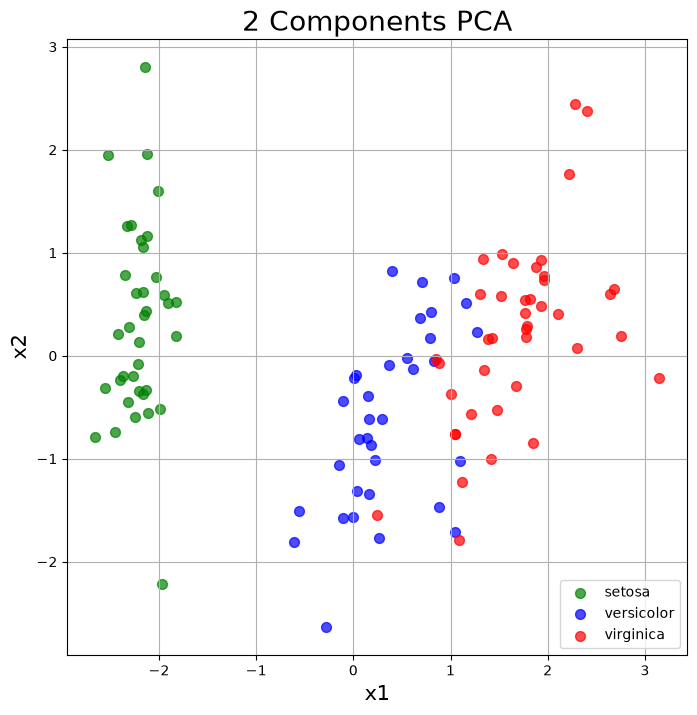

Explained variance ratio: [0.72216128 0.24132364]
Cumulative variance explained: [0.72216128 0.96348492]
DataFrame columns: ['x1', 'x2', 'Species']


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('./flowers.csv')
X = df[list(df.columns)[:-1]]
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)  

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Create a dataframe with PCA results and labels
new_x = pd.DataFrame(data=X_train_pca, columns=['x1', 'x2'])
df2 = pd.concat([new_x, y_train.reset_index(drop=True)], axis=1)

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1) 
ax.set_xlabel('x1', fontsize=15)
ax.set_ylabel('x2', fontsize=15)
ax.set_title('2 Components PCA', fontsize=20)

# Use correct species names from the data
species_names = ['setosa', 'versicolor', 'virginica']
colors = ['g', 'b', 'r']

for species, color in zip(species_names, colors):
    mask = df2['Species'] == species
    ax.scatter(df2.loc[mask, 'x1'], 
               df2.loc[mask, 'x2'], 
               c=color, 
               label=species,
               alpha=0.7,
               s=50)
ax.legend()
ax.grid()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative variance explained:", np.cumsum(pca.explained_variance_ratio_))
print("DataFrame columns:", df2.columns.tolist())